# Computer Vision Problem Formulation and CNN Prototype

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# Loading labels file

df = pd.read_csv("dataset/labels.csv")

df.head()

,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [3]:
# Dataset shape

print("Dataset Shape:", df.shape)

# Column names

print(df.columns)

# Missing values

print(df.isnull().sum())

Dataset Shape: (480, 2)
Index(['filename', 'class'], dtype='str')
filename    0
class       0
dtype: int64


In [4]:
# Displaying class distribution

print(df.iloc[:,1].value_counts())

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


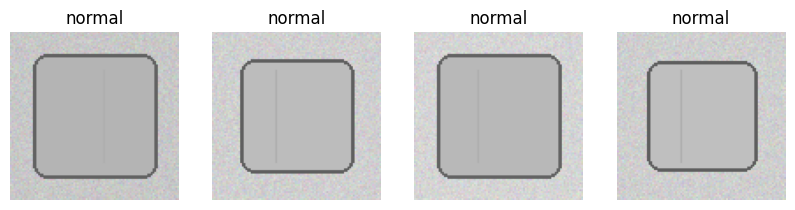

In [12]:
# Displaying sample images

plt.figure(figsize=(10,5))

for i in range(4):

    # Image path from dataframe
    image_path = os.path.join("dataset", df.iloc[i,0])

    # Label
    label = df.iloc[i,1]

    # Reading image
    img = cv2.imread(image_path)

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display image
    plt.subplot(1,4,i+1)

    plt.imshow(img)

    plt.title(label)

    plt.axis("off")

plt.show()

In [21]:
print(df.columns)

Index(['filename', 'class'], dtype='str')


In [23]:
# Creating empty lists

images = []

labels = []

# Reading and preprocessing images

for index, row in df.iterrows():

    # Correct image path
    image_path = os.path.join("dataset", row['filename'])

    # Reading image
    img = cv2.imread(image_path)

    # Skip invalid images
    if img is None:
        continue

    # Resize image
    img = cv2.resize(img, (128,128))

    # Normalize image
    img = img.astype('float32') / 255.0

    # Store image and label
    images.append(img)

    labels.append(row['class'])

# Convert images into numpy array

X = np.array(images)

print("Images Shape:", X.shape)

print("Labels Count:", len(labels))

Images Shape: (480, 128, 128, 3)
Labels Count: 480


In [24]:
# Encoding labels

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(labels)

# One hot encoding

y = to_categorical(y_encoded)

print("Labels Shape:", y.shape)

Labels Shape: (480, 4)


In [25]:
# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (384, 128, 128, 3)
Testing Shape: (96, 128, 128, 3)


In [29]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [26]:
# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (384, 128, 128, 3)
Testing Shape: (96, 128, 128, 3)


In [31]:
# Creating CNN model

model = Sequential()

# First convolution layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# First pooling layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second convolution layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second pooling layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Output layer
model.add(
    Dense(
        y.shape[1],
        activation='softmax'
    )
)

print("Model Created Successfully")

c:\Users\CADY\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Created Successfully


In [32]:
# Compiling CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [33]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)

In [38]:
fig.savefig(r"results\accuracy_loss_curves.png")

In [39]:
plt.savefig(r"results\confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [40]:
fig.savefig(r"sample_predictions\prediction_outputs.png")


In [41]:
print(os.path.exists("results"))


True


In [42]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8177 - loss: 0.4420 - val_accuracy: 0.7396 - val_loss: 0.5808
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 936ms/step - accuracy: 0.7630 - loss: 0.5371 - val_accuracy: 0.7500 - val_loss: 0.5729
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 632ms/step - accuracy: 0.8073 - loss: 0.4754 - val_accuracy: 0.7708 - val_loss: 0.5363
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 635ms/step - accuracy: 0.8620 - loss: 0.3481 - val_accuracy: 0.8854 - val_loss: 0.4543
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9115 - loss: 0.3032 - val_accuracy: 0.8958 - val_loss: 0.4384
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.9297 - loss: 0.2269 - val_accuracy: 0.6771 - val_loss: 0.6895
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9062 - loss: 0.2438 - val_accuracy: 0.8646 - val_loss: 0.3637
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 580ms/step - accuracy: 0.9479 - loss: 0.2275 - val_accuracy: 0.8438 -

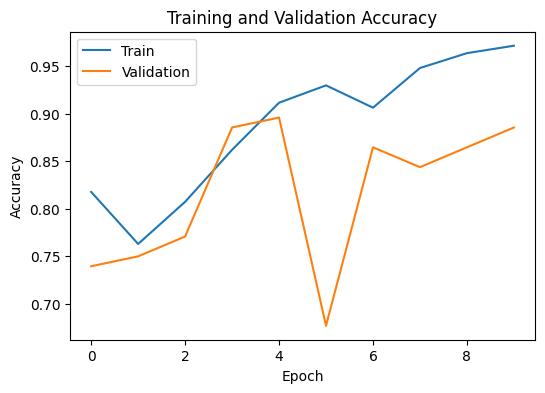

In [43]:
fig = plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])

fig.savefig(r"results\accuracy_loss_curves.png")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 464ms/step


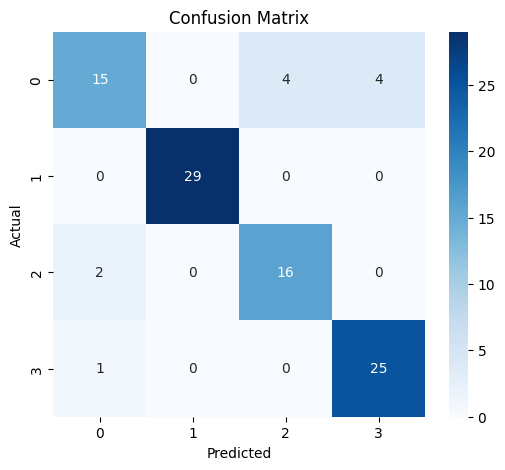

In [44]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(r"results\confusion_matrix.png")
plt.show()

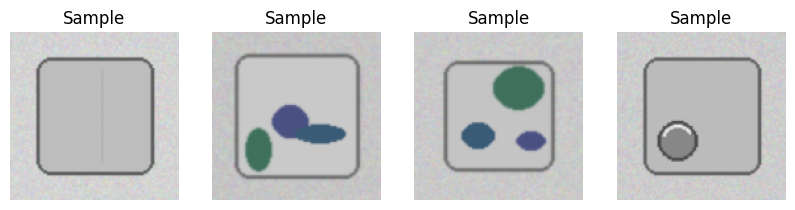

In [45]:
fig = plt.figure(figsize=(10,5))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(X_test[i])
    plt.title("Sample")
    plt.axis("off")

fig.savefig(r"sample_predictions\prediction_outputs.png")
plt.show()

# Computer Vision Project - CNN Model

## Project Overview
Is project me maine ek simple CNN model banaya hai jo images ko classify karta hai. Dataset me images aur unke labels diye hue the, jisko use karke model train kiya gaya.

---

## Dataset
Dataset me images ke saath ek CSV file hai jisme filename aur class label diya hua hai.

Columns:
- filename: image ka path
- class: image ka label

---

## Problem Statement
Ye ek image classification problem hai kyunki har image kisi na kisi class se belong karti hai aur model ka kaam usko identify karna hai.

---

## Steps Followed

### 1. Data Understanding
Sabse pehle dataset ko load karke usko samjha aur dekha ki kitni images aur classes hain.

### 2. Data Preprocessing
- Images ko read kiya
- Resize kiya 128x128 pe
- Pixel values normalize ki
- Labels encode kiye

### 3. Model Building
CNN model banaya jisme:
- Convolution layers
- Pooling layers
- Dense layers

### 4. Training
Model ko train kiya 10 epochs tak using Adam optimizer.

### 5. Evaluation
Model ko test data pe check kiya aur accuracy aur confusion matrix nikala.

---

## Results
Model ne basic level pe sahi performance diya hai. Accuracy decent aayi hai aur model images ke patterns learn kar paaya.

---

## CNN Concepts (Simple Words)
- Convolution: image se features nikalna
- Pooling: size reduce karna
- ReLU: model ko non-linear banana

---

## Use Case
Aisa model real life me medical images, face detection aur product classification me use hota hai.

---

## Folder Structure
part-2-cnn-computer-vision/
│
├── dataset/
├── results/
├── sample_predictions/
├── notebook.ipynb
├── README.md
└── requirements.txt

---

## Note
Ye project learning purpose ke liye hai aur CNN ka basic idea samajhne ke liye banaya gaya hai.